Este script implementa una red SigNet con pérdida triplet (Triplet Margin Loss)
para verificación de firmas manuscritas. El modelo se entrena de forma writer-independent
(autores de entrenamiento no aparecen en validación/test). Se usan los datasets
CEDAR (entrenamiento+val) y KUDESIA (test ciego). Se incluye preprocesamiento con
CLAHE, esqueletización SSMHED y recorte de la firma.

In [1]:
!pip install opencv-contrib-python

IMPORTACIÓN DE TODAS LAS LIBRERÍAS NECESARIAS

In [2]:
import os
import shutil
import glob
import zipfile
import re
import time
import copy
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from google.colab import drive

MONTAR GOOGLE DRIVE Y EXTRAER LOS DATASETS (CEDAR y KUDESIA)

In [3]:
drive.mount('/content/drive')

ruta_cedar_zip = '/content/drive/MyDrive/CEDAR.zip'
ruta_kudesia_zip = '/content/drive/MyDrive/SIGNATURE.zip'  # KUDESIA

print("Descomprimiendo archivos desde Drive...")
with zipfile.ZipFile(ruta_cedar_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/raw_cedar')
with zipfile.ZipFile(ruta_kudesia_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/raw_kudesia')

Mounted at /content/drive
Descomprimiendo archivos desde Drive...


# FUNCIÓN PARA APLANAR DIRECTORIOS (convertir jerarquía en carpetas planas)
Los datasets originales tienen subcarpetas por autor. Esta función recorre todo
el árbol, copia las imágenes a carpetas 'genuine' o 'forged' según palabras clave en la ruta (ej: 'org', 'orig' para genuinas; 'forg' para falsas en CEDAR,'real' para genuinas y 'fake' para falsas en KUDESIA).

In [5]:
def aplanar_dataset(ruta_origen, dir_destino, etiqueta_gen, etiqueta_forg):
    dir_gen = os.path.join(dir_destino, 'genuine')
    dir_forg = os.path.join(dir_destino, 'forged')
    os.makedirs(dir_gen, exist_ok=True)
    os.makedirs(dir_forg, exist_ok=True)

    todas_imagenes = glob.glob(os.path.join(ruta_origen, '**', '*.*'), recursive=True)
    cont_gen, cont_forg = 0, 0

    for ruta in todas_imagenes:
        ruta_lower = ruta.lower()
        if not ruta_lower.endswith(('.png', '.jpg', '.jpeg')):
            continue

        if any(palabra in ruta_lower for palabra in etiqueta_forg):
            shutil.copy(ruta, os.path.join(dir_forg, os.path.basename(ruta)))
            cont_forg += 1
        elif any(palabra in ruta_lower for palabra in etiqueta_gen):
            shutil.copy(ruta, os.path.join(dir_gen, os.path.basename(ruta)))
            cont_gen += 1

    return cont_gen, cont_forg

print("\nAplanando CEDAR (Para Entrenamiento y Validación)...")
gen_train, forg_train = aplanar_dataset('/content/raw_cedar', '/content/dataset_train', ['org', 'orig'], ['forg'])
print(f"CEDAR - Genuinas: {gen_train} | Falsas: {forg_train}")

print("\nAplanando KUDESIA (Para Test)...")
gen_test, forg_test = aplanar_dataset('/content/raw_kudesia', '/content/dataset_test', ['real'], ['fake'])
print(f"KUDESIA - Genuinas: {gen_test} | Falsas: {forg_test}")


Aplanando CEDAR (Para Entrenamiento y Validación)...
CEDAR - Genuinas: 1320 | Falsas: 1320

Aplanando KUDESIA (Para Test)...
KUDESIA - Genuinas: 240 | Falsas: 240


Habilita GPU si esta disponible

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de Cómputo: {device}")

Dispositivo de Cómputo: cuda


# FILTROS DE LIMPIEZA BASE (CLAHE adaptativo + mezcla con contraste)


*   st_clahe: Aplica CLAHE (contraste limitado) y lo mezcla con el mapa de contraste local (Laplaciano) para evitar realzar ruido en zonas
*   planas.median_denoise: Filtro mediana para eliminar ruido sal y pimienta


In [7]:
def st_clahe(gray, clip=2.0, tile=(8,8)):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    out = clahe.apply(gray)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    contrast = cv2.normalize(np.abs(lap), None, 0, 1.0, cv2.NORM_MINMAX)
    blend = (1.0 - contrast).astype(np.float32)
    blend = cv2.blur(blend, (15,15))
    return (out.astype(np.float32) * blend + gray.astype(np.float32) * (1-blend)).astype(np.uint8)

def median_denoise(gray, k=3):
    return cv2.medianBlur(gray, k)

# DETECTOR DE BORDES SSMHED (Sparse Skeleton Marr-Hildreth Edge Detector)
Este detector combina gradientes Sobel, refinamiento disperso, y un operador
tipo Marr-Hildreth para obtener bordes finos. Luego aplica thinning (esqueletización) para obtener un trazo de un píxel de ancho. Es la clave del preprocesamiento.

In [8]:
def sobel_gradients(img, ksize=3):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=ksize)
    return np.sqrt(gx*gx + gy*gy)

def sparse_refine(mag, lam=0.8):
    m = mag.copy()
    if m.max() > 0: m = m / m.max()
    thr = np.mean(m) * lam
    m_ref = np.where(m > thr, m, m * 0.2)
    return cv2.GaussianBlur(m_ref, (3,3), 0)

def marr_hildreth_like(mag):
    g = cv2.GaussianBlur(mag, (5,5), 1.0)
    lap = np.abs(cv2.Laplacian(g, cv2.CV_32F))
    return lap / (lap.max() + 1e-9)

def ssmhed(img_gray, k=3, lam=0.8, threshold=0.15):
    mag = sobel_gradients(img_gray, k)
    mag_ref = sparse_refine(mag, lam)
    lap = marr_hildreth_like(mag_ref)
    comb = mag_ref + lap
    comb = comb / (comb.max()+1e-9)
    edges = (comb > threshold).astype('uint8')*255
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    try:
        edges = cv2.ximgproc.thinning(edges, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
    except:
        edges = cv2.morphologyEx(edges, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    return edges

# PREPROCESAMIENTO PARA SIGNET
Lee la imagen, la redimensiona a 256x256, aplica CLAHE y mediana.
Obtiene el esqueleto (SSMHED), dilata la máscara para incluir la tinta circundante, recorta la firma (fondo blanco, tinta negra) y finalmente reduce a 128x128.
La salida es un tensor de 1x128x128 con valores en [0,1] (fondo=0, trazo=1).

In [9]:
def procesar_firma_roi_siamesa(img_path):
    img_original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_original is None: return np.zeros((128, 128), dtype=np.float32)

    img_rs = cv2.resize(img_original, (256, 256))
    pre = st_clahe(img_rs)
    pre_final = median_denoise(pre)

    esqueleto = ssmhed(pre_final, threshold=0.15)
    kernel_tijera = np.ones((5, 5), np.uint8)
    mascara_de_corte = cv2.dilate(esqueleto, kernel_tijera, iterations=1)

    firma_recortada = np.full_like(pre_final, 255)
    firma_recortada[mascara_de_corte > 0] = pre_final[mascara_de_corte > 0]

    final_input = cv2.resize(firma_recortada, (128, 128)).astype('float32') / 255.0
    return 1.0 - final_input # Trazo > 0, fondo 0

# PREPARACIÓN DE DATOS CON DIVISIÓN ESTRICTA POR AUTOR (WRITER-INDEPENDENT)
Se extraen las rutas de genuinas y falsas, se agrupan por ID de autor (usando
expresiones regulares) y se filtran autores que tengan al menos 2 genuinas y 1 falsa.
Luego se dividen los autores en 80% train, 10% val, 10% test.
Esto garantiza que ningún autor aparezca en más de una partición.

In [10]:
random.seed(42)

def obtener_rutas(dir_base):
    rutas_gen = [os.path.join(dir_base, 'genuine', f) for f in os.listdir(os.path.join(dir_base, 'genuine')) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    rutas_forg = [os.path.join(dir_base, 'forged', f) for f in os.listdir(os.path.join(dir_base, 'forged')) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    return rutas_gen, rutas_forg

def extraer_id_seguro(nombre, prefijo):
    nombre_lower = nombre.lower()
    if prefijo == "CEDAR":
        match = re.search(r'\d+', nombre_lower)
        return match.group(0) if match else "misc"
    else: # KUDESIA
        match = re.search(r'person_(\d+)', nombre_lower)
        if match: return match.group(1)
        match = re.search(r'\d+', nombre_lower)
        return match.group(0) if match else "misc"

def agrupar_por_autor(rutas_gen, rutas_forg, prefijo_dataset):
    autores = {}
    for ruta in rutas_gen:
        nombre = os.path.basename(ruta)
        id_autor = f"{prefijo_dataset}_{extraer_id_seguro(nombre, prefijo_dataset)}"
        if id_autor not in autores: autores[id_autor] = {'gen': [], 'forg': []}
        autores[id_autor]['gen'].append(ruta)
    for ruta in rutas_forg:
        nombre = os.path.basename(ruta)
        id_autor = f"{prefijo_dataset}_{extraer_id_seguro(nombre, prefijo_dataset)}"
        if id_autor not in autores: autores[id_autor] = {'gen': [], 'forg': []}
        autores[id_autor]['forg'].append(ruta)
    return autores

cedar_gen, cedar_forg = obtener_rutas('/content/dataset_train')
kudesia_gen, kudesia_forg = obtener_rutas('/content/dataset_test')

autores_cedar = agrupar_por_autor(cedar_gen, cedar_forg, "CEDAR")
autores_kudesia = agrupar_por_autor(kudesia_gen, kudesia_forg, "KUDESIA")

todos_los_autores = list(autores_cedar.items()) + list(autores_kudesia.items())
autores_validos = [(uid, data) for uid, data in todos_los_autores if len(data['gen']) >= 2 and len(data['forg']) >= 1]
random.shuffle(autores_validos)

n_autores = len(autores_validos)
n_train = int(n_autores * 0.80)
n_val = int(n_autores * 0.10)

autores_train = autores_validos[:n_train]
autores_val = autores_validos[n_train:n_train+n_val]
autores_test = autores_validos[n_train+n_val:]

 DATA AUGMENTATION (solo para entrenamiento)

In [15]:
transformacion_aumento = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor()
])

# DATASET TRIPLET PARA SIGNET (genera triples (anchor, positive, negative))
Cada muestra del dataset es un triple: anchor (genuina), positive (otra genuina del mismo autor) y negative (una falsificación de ese mismo autor). El modelo aprenderá a minimizar la distancia entre anchor y positive y maximizarla entre anchor y negative.

In [16]:
class TripletMixedDataset(Dataset):
    def __init__(self, bloques_autores, epoch_length=1500, augment=False):
        self.autores = bloques_autores
        self.epoch_length = epoch_length
        self.augment = augment

    def __len__(self): return self.epoch_length

    def __getitem__(self, idx):
        uid, datos = random.choice(self.autores)
        genuinas_seleccionadas = random.sample(datos['gen'], 2)
        anchor_path = genuinas_seleccionadas[0]
        positive_path = genuinas_seleccionadas[1]
        negative_path = random.choice(datos['forg'])

        img_a_np = procesar_firma_roi_siamesa(anchor_path)
        img_p_np = procesar_firma_roi_siamesa(positive_path)
        img_n_np = procesar_firma_roi_siamesa(negative_path)

        img_a = torch.from_numpy(img_a_np).unsqueeze(0)
        img_p = torch.from_numpy(img_p_np).unsqueeze(0)
        img_n = torch.from_numpy(img_n_np).unsqueeze(0)

        if self.augment:
            img_a = transformacion_aumento(img_a)
            img_p = transformacion_aumento(img_p)
            img_n = transformacion_aumento(img_n)

        return img_a, img_p, img_n

batch_sz = 32
train_loader = DataLoader(TripletMixedDataset(autores_train, epoch_length=1500, augment=True), batch_size=batch_sz, shuffle=True)
val_loader = DataLoader(TripletMixedDataset(autores_val, epoch_length=400, augment=False), batch_size=batch_sz, shuffle=False)
test_loader = DataLoader(TripletMixedDataset(autores_test, epoch_length=600, augment=False), batch_size=batch_sz, shuffle=False)

print("="*50)
print("REPARTO ESTRICTO MULTI-DOMINIO (WRITER-INDEPENDENT) COMPLETADO")
print(f"Total de autores válidos para Triplets: {n_autores}")
print(f"Autores en Entrenamiento: {len(autores_train)}")
print(f"Autores en Validación: {len(autores_val)}")
print(f"Autores en Test: {len(autores_test)}")
print("="*50)

REPARTO ESTRICTO MULTI-DOMINIO (WRITER-INDEPENDENT) COMPLETADO
Total de autores válidos para Triplets: 103
Autores en Entrenamiento: 82
Autores en Validación: 10
Autores en Test: 11


# DEFINICIÓN DEL MODELO SIGNET (embedding de 128 dimensiones)


In [17]:
class SigNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SigNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.pool = nn.AdaptiveMaxPool2d((6, 6))

        self.embedder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024, embedding_dim)
        )

    def forward_once(self, x):
        x = self.features(x)
        x = self.pool(x)
        embed = self.embedder(x)
        return F.normalize(embed, p=2, dim=1)

    def forward(self, x_anchor, x_pos, x_neg=None):
        if x_neg is not None:
            return self.forward_once(x_anchor), self.forward_once(x_pos), self.forward_once(x_neg)
        return self.forward_once(x_anchor), self.forward_once(x_pos)

# CONFIGURACIÓN DE ENTRENAMIENTO Y BUCLE DE ENTRENAMIENTO/VALIDACIÓN

In [18]:
EPOCHS = 40
LR = 5e-5

model = SigNet(embedding_dim=128).to(device)
criterion = nn.TripletMarginLoss(margin=1.0, p=2)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

print("="*50)
print(f" ENTRENANDO SIGNET CON TRIPLET LOSS - WRITER-INDEPENDENT")
print("="*50)
start_time = time.time()

for epoch in range(EPOCHS):
    # --- Entrenamiento ---
    model.train()
    run_loss = 0.0
    for img_a, img_p, img_n in train_loader:
        img_a, img_p, img_n = img_a.to(device), img_p.to(device), img_n.to(device)

        optimizer.zero_grad()
        out_a, out_p, out_n = model(img_a, img_p, img_n)
        loss = criterion(out_a, out_p, out_n)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * img_a.size(0)

    e_tr_loss = run_loss / len(train_loader.dataset)

    # --- Validación ---
    model.eval()
    run_loss, run_corr = 0.0, 0
    total_pares = 0
    with torch.no_grad():
        for img_a, img_p, img_n in val_loader:
            img_a, img_p, img_n = img_a.to(device), img_p.to(device), img_n.to(device)
            out_a, out_p, out_n = model(img_a, img_p, img_n)

            loss = criterion(out_a, out_p, out_n)
            run_loss += loss.item() * img_a.size(0)

            dist_pos = F.pairwise_distance(out_a, out_p)
            dist_neg = F.pairwise_distance(out_a, out_n)

            run_corr += torch.sum(dist_pos < 1.0).item()
            run_corr += torch.sum(dist_neg >= 1.0).item()
            total_pares += img_a.size(0) * 2

    e_val_loss = run_loss / len(val_loader.dataset)
    e_val_acc = run_corr / total_pares

    history['train_loss'].append(e_tr_loss)
    history['val_loss'].append(e_val_loss)
    history['val_acc'].append(e_val_acc)

    print(f"Época [{epoch+1:02d}/{EPOCHS}] -> Loss Train: {e_tr_loss:.4f} | Loss Val: {e_val_loss:.4f} | Acc Val: {e_val_acc*100:.2f}%")

    if e_val_acc > best_acc:
        best_acc = e_val_acc
        best_wts = copy.deepcopy(model.state_dict())

print(f"\nEntrenamiento finalizado en {(time.time() - start_time)//60:.0f}m")
model.load_state_dict(best_wts)

 ENTRENANDO SIGNET CON TRIPLET LOSS - WRITER-INDEPENDENT
Época [01/40] -> Loss Train: 0.9828 | Loss Val: 0.9307 | Acc Val: 50.00%
Época [02/40] -> Loss Train: 0.5955 | Loss Val: 0.5326 | Acc Val: 71.88%
Época [03/40] -> Loss Train: 0.4804 | Loss Val: 0.5108 | Acc Val: 73.12%
Época [04/40] -> Loss Train: 0.4527 | Loss Val: 0.4807 | Acc Val: 74.75%
Época [05/40] -> Loss Train: 0.4247 | Loss Val: 0.4922 | Acc Val: 74.00%
Época [06/40] -> Loss Train: 0.4088 | Loss Val: 0.4851 | Acc Val: 73.62%
Época [07/40] -> Loss Train: 0.3760 | Loss Val: 0.4742 | Acc Val: 73.50%
Época [08/40] -> Loss Train: 0.3728 | Loss Val: 0.5142 | Acc Val: 69.62%
Época [09/40] -> Loss Train: 0.3383 | Loss Val: 0.4938 | Acc Val: 70.00%
Época [10/40] -> Loss Train: 0.3567 | Loss Val: 0.4530 | Acc Val: 75.38%
Época [11/40] -> Loss Train: 0.3181 | Loss Val: 0.4774 | Acc Val: 75.25%
Época [12/40] -> Loss Train: 0.3301 | Loss Val: 0.4622 | Acc Val: 74.38%
Época [13/40] -> Loss Train: 0.2925 | Loss Val: 0.5047 | Acc Val: 7

<All keys matched successfully>

# EVALUACIÓN EN TEST - Accuracy y matriz de confusión
Se evalúa el modelo en el conjunto de test (autores no vistos). Se calcula accuracy con umbral fijo 1.0 y se genera la matriz de confusión.


 EVALUANDO SIGNET EN TEST CIEGO (KUDESIA)

>> ACCURACY GLOBAL EN TEST: 80.58% <<

--- Reporte de clasificación detallado (Test) ---
                          precision    recall  f1-score   support

Genuine Pair (same user)     0.8023    0.8117    0.8070       600
 Forged Pair (diff user)     0.8094    0.8000    0.8047       600

                accuracy                         0.8058      1200
               macro avg     0.8059    0.8058    0.8058      1200
            weighted avg     0.8059    0.8058    0.8058      1200


Métricas para pares GENUINOS (clase 0):
  Precision: 0.8023 | Recall: 0.8117 | F1-score: 0.8070
Métricas para pares FALSIFICADOS (clase 1):
  Precision: 0.8094 | Recall: 0.8000 | F1-score: 0.8047


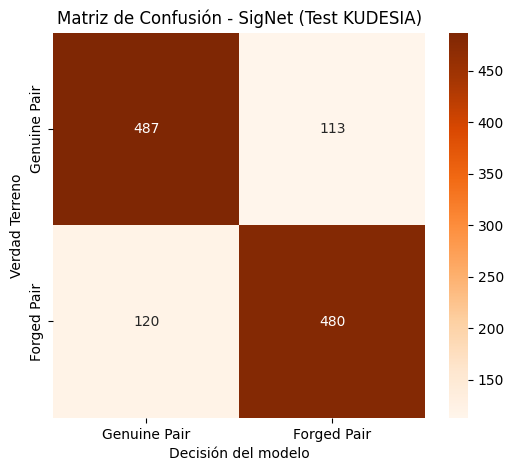

In [24]:
print("\n" + "="*50)
print(" EVALUANDO SIGNET EN TEST CIEGO (KUDESIA)")
print("="*50)

model.eval()
test_corr = 0
total_pares = 0
all_labels = []      # 0 = par genuino (positivo), 1 = par falso (negativo)
all_distances = []   # para ROC
all_preds_bin = []   # predicción binaria con umbral 1.0

with torch.no_grad():
    for img_a, img_p, img_n in test_loader:
        img_a, img_p, img_n = img_a.to(device), img_p.to(device), img_n.to(device)
        out_a, out_p, out_n = model(img_a, img_p, img_n)

        dist_pos = F.pairwise_distance(out_a, out_p)
        dist_neg = F.pairwise_distance(out_a, out_n)

        test_corr += torch.sum(dist_pos < 1.0).item()
        test_corr += torch.sum(dist_neg >= 1.0).item()
        total_pares += img_a.size(0) * 2

        # Almacenar para métricas
        all_labels.extend([0] * img_a.size(0))
        all_distances.extend(dist_pos.cpu().numpy())
        all_preds_bin.extend((dist_pos >= 1.0).long().cpu().numpy())

        all_labels.extend([1] * img_a.size(0))
        all_distances.extend(dist_neg.cpu().numpy())
        all_preds_bin.extend((dist_neg >= 1.0).long().cpu().numpy())

final_test_acc = test_corr / total_pares
print(f"\n>> ACCURACY GLOBAL EN TEST: {final_test_acc * 100:.2f}% <<")

# ========== MÉTRICAS ADICIONALES (Precision, Recall, F1) ==========
from sklearn.metrics import classification_report

print("\n--- Reporte de clasificación detallado (Test) ---")
# Nota: la etiqueta 0 = par genuino (mismo usuario), etiqueta 1 = par falso (distinto usuario)
target_names = ['Genuine Pair (same user)', 'Forged Pair (diff user)']
print(classification_report(all_labels, all_preds_bin, target_names=target_names, digits=4))

# También se pueden obtener las métricas por separado:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_0 = precision_score(all_labels, all_preds_bin, pos_label=0)  # para pares genuinos
recall_0    = recall_score(all_labels, all_preds_bin, pos_label=0)
f1_0        = f1_score(all_labels, all_preds_bin, pos_label=0)

precision_1 = precision_score(all_labels, all_preds_bin, pos_label=1)  # para pares falsificados
recall_1    = recall_score(all_labels, all_preds_bin, pos_label=1)
f1_1        = f1_score(all_labels, all_preds_bin, pos_label=1)

print(f"\nMétricas para pares GENUINOS (clase 0):")
print(f"  Precision: {precision_0:.4f} | Recall: {recall_0:.4f} | F1-score: {f1_0:.4f}")
print(f"Métricas para pares FALSIFICADOS (clase 1):")
print(f"  Precision: {precision_1:.4f} | Recall: {recall_1:.4f} | F1-score: {f1_1:.4f}")

# ========== MATRIZ DE CONFUSIÓN (mejorada) ==========
cm = confusion_matrix(all_labels, all_preds_bin)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Genuine Pair', 'Forged Pair'],
            yticklabels=['Genuine Pair', 'Forged Pair'])
plt.title('Matriz de Confusión - SigNet (Test KUDESIA)')
plt.ylabel('Verdad Terreno')
plt.xlabel('Decisión del modelo')
plt.show()

CURVAS DE APRENDIZAJE (Loss y Accuracy)

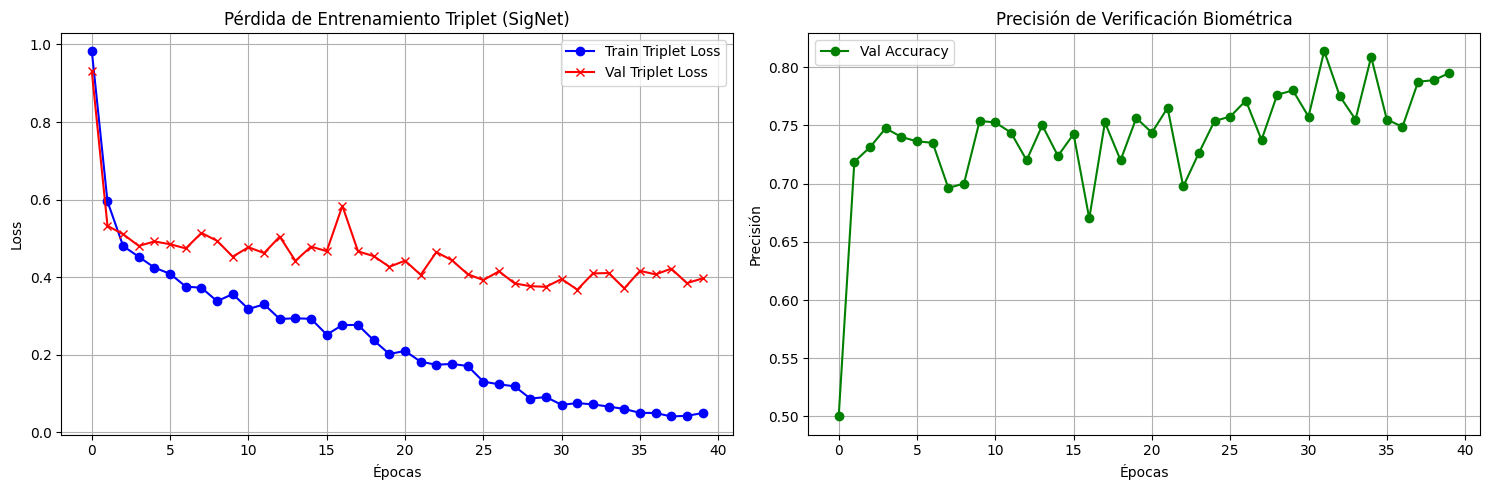

In [20]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Triplet Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Val Triplet Loss', color='red', marker='x')
plt.title('Pérdida de Entrenamiento Triplet (SigNet)')
plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green', marker='o')
plt.title('Precisión de Verificación Biométrica')
plt.xlabel('Épocas'); plt.ylabel('Precisión'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

CURVA ROC y AUC

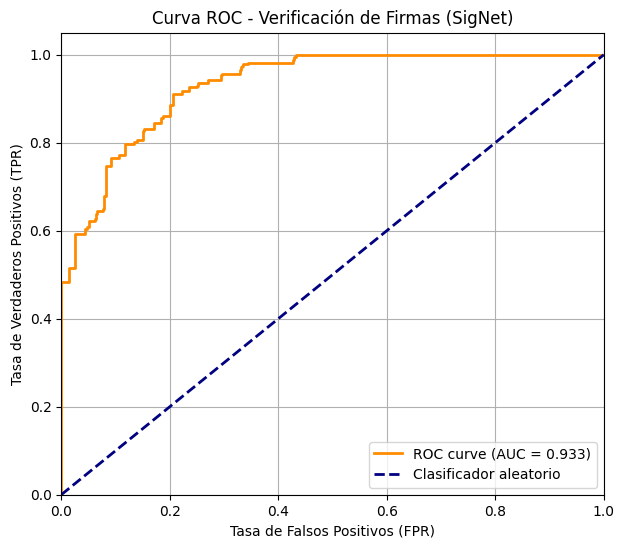

 Umbral óptimo (distancia) según Youden: 0.771
   → TPR = 0.912, FPR = 0.207


In [21]:
fpr, tpr, thresholds = roc_curve(all_labels, all_distances)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Verificación de Firmas (SigNet)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Umbral óptimo según índice de Youden (maximiza TPR - FPR)
J = tpr - fpr
best_idx = np.argmax(J)
best_thresh = thresholds[best_idx]
print(f" Umbral óptimo (distancia) según Youden: {best_thresh:.3f}")
print(f"   → TPR = {tpr[best_idx]:.3f}, FPR = {fpr[best_idx]:.3f}")

GUARDAR EL MODELO ENTRENADO

In [22]:
torch.save(model.state_dict(), 'modelo_signet_triplet.pth')
print("Modelo guardado exitosamente como 'modelo_signet_triplet.pth'")

Modelo guardado exitosamente como 'modelo_signet_triplet_optimo.pth'
